# Strait closure classifiers

One row = (episode, week, strait). Features: what the agent sees that week. Labels: what truly happens next (`truth/o`).

- `TASK = "onset"`: the strait is open now (≥ 50 %); will it fall below 50 % within the next `H` weeks?
- `TASK = "still"`: the strait is closed now (< 50 %); will it still be closed in `H` weeks?

Data: `examples/collect_data.py` (train `small_e1001`, held out `small_e1002`). Needs `uv add --dev scikit-learn pandas`.

In [17]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
TRAIN, VALID = ROOT / "data/small_e1001", ROOT / "data/small_e1002"
HORIZONS = (1, 2, 4, 8)
TASK, H = "still", 4
CLOSED = 0.5
SEARCH_EPISODES, N_ITER, CV_FOLDS = 400, 12, 3
SCORING = "average_precision"
SEED = 0
rng = np.random.default_rng(SEED)

## Dataset

In [18]:
meta = json.loads((TRAIN / "meta.json").read_text())
T = meta["T"]
straits = meta["layout"]["chokepoints"]
names = [meta["nodes"]["id"][c].removeprefix("chk_") for c in straits]
C = len(straits)
units = [tuple(u) for u in meta["layout"]["warning_units"]]
W_STRAIT = [units.index(("chokepoint", c)) for c in straits]
W_OTHER = [i for i, u in enumerate(units) if u[0] != "chokepoint"]
OTHER_NAMES = [
    f"w_{meta['regions'][u[1]]}" if u[0] == "region" else f"w_dyad{u[1]}" for u in (units[i] for i in W_OTHER)
]
channels = meta["codes"]["messages.channel"]
MID, TIES = channels.index("mid_threat"), channels.index("ties_threat")


def lag(x, k):
    return np.concatenate([np.repeat(x[:1], k, 0), x[:-k]]) if k else x


def ahead(x, k):
    out = np.full_like(x, np.nan, dtype=np.float64)
    out[: len(x) - k] = x[k:]
    return out


def episode_frame(path, episode):
    ep = np.load(path)
    w = ep["obs/warning.score"] * ep["obs/warning.score.observed"]
    ws, wo = w[:, W_STRAIT], w[:, W_OTHER]
    opn = ep["obs/graph_now.open"]
    kap = ep["obs/graph_now.kappa.ct"] / np.maximum(ep["obs/graph_now.kappa.ct"][:1], 1e-9)
    closed_for = np.zeros((T, C))
    for t in range(T):
        closed_for[t] = ((closed_for[t - 1] if t else 0) + 1) * (opn[t] < 1)

    mw, tk, tg, ch = (ep[f"messages/{k}"] for k in ("week", "target_kind", "target", "channel"))
    about = np.zeros((T, C))
    for i, c in enumerate(straits):
        np.add.at(about[:, i], mw[(tk == 0) & (tg == c)] - 1, 1)
    mid, ties = np.zeros(T), np.zeros(T)
    np.add.at(mid, mw[ch == MID] - 1, 1)
    np.add.at(ties, mw[ch == TIES] - 1, 1)

    announced, to_end = np.zeros((T, C)), np.zeros((T, C))
    for wk, c, end, seen in zip(
        *(ep[f"closure_end/{k}"] for k in ("week", "chokepoint", "end_week", "end_week.observed"))
    ):
        if seen and c in straits:
            announced[wk - 1, straits.index(c)] = 1
            to_end[wk - 1, straits.index(c)] = end - wk

    lags = np.stack([lag(ws, k) for k in range(4)])
    per_strait = {
        "warn": ws,
        "warn_l1": lags[1],
        "warn_l2": lags[2],
        "warn_l3": lags[3],
        "warn_mean4": lags.mean(0),
        "warn_max4": lags.max(0),
        "warn_chg": ws - lags[1],
        "open": opn,
        "closed_for": closed_for,
        "kappa": kap,
        "war_risk": ep["obs/graph_now.war_risk"],
        "msgs_strait": about,
        "end_announced": announced,
        "weeks_to_end": to_end,
    }
    shared = {
        "mid_threats": mid,
        "ties_threats": ties,
        "warn_other_max": wo.max(1),
        "warn_other_mean": wo.mean(1),
        "week_frac": np.arange(1, T + 1) / T,
        **dict(zip(OTHER_NAMES, wo.T)),
    }

    o = ep["truth/o"].astype(np.float64)
    labels = {}
    for h in HORIZONS:
        window = np.nanmin(np.stack([ahead(o, k) for k in range(h)]), 0)
        labels[f"closes_{h}"] = window < CLOSED
        labels[f"still_{h}"] = ahead(o, h - 1) < CLOSED
        labels[f"full_{h}"] = np.repeat((np.arange(T) + h <= T)[:, None], C, 1)

    cols = {
        "episode": np.full(T * C, episode),
        "week": np.repeat(np.arange(1, T + 1), C),
        "strait": np.tile(np.arange(C), T),
    }
    cols |= {k: v.reshape(-1).astype(np.float32) for k, v in per_strait.items()}
    cols |= {k: np.repeat(v, C).astype(np.float32) for k, v in shared.items()}
    cols |= {k: v.reshape(-1) for k, v in labels.items()}
    return pd.DataFrame(cols)


def load(folder, episodes=None):
    files = sorted(folder.glob("ep?????.npz"))[:episodes]
    start = time.perf_counter()
    df = pd.concat([episode_frame(f, int(f.stem[2:])) for f in files], ignore_index=True)
    print(f"{folder.name}: {len(files)} episodes, {len(df):,} rows, {time.perf_counter() - start:.0f} s")
    return df

In [19]:
train = load(TRAIN)
if VALID.is_dir():
    valid = load(VALID)
else:
    cut = train["episode"].quantile(0.8)
    train, valid = train[train["episode"] <= cut].copy(), train[train["episode"] > cut].copy()
    print(f"no {VALID.name}: held out the last 20 % of {TRAIN.name}'s episodes")
for df in (train, valid):
    for i, n in enumerate(names):
        df[f"s_{n}"] = (df["strait"] == i).astype(np.float32)
train.head()

small_e1001: 2000 episodes, 728,000 rows, 5 s
no small_e1002: held out the last 20 % of small_e1001's episodes


,episode,week,strait,warn,warn_l1,warn_l2,warn_l3,warn_mean4,warn_max4,warn_chg,...,closes_8,still_8,full_8,s_hormuz,s_malacca,s_suez,s_cape,s_taiwan,s_panama,s_turkish
0,0,1,0,-0.710680,-0.710680,-0.710680,-0.710680,-0.710680,-0.710680,0.0,...,False,False,True,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1,-1.118702,-1.118702,-1.118702,-1.118702,-1.118702,-1.118702,0.0,...,False,False,True,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,1,2,-0.172616,-0.172616,-0.172616,-0.172616,-0.172616,-0.172616,0.0,...,False,False,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0,1,3,0.498209,0.498209,0.498209,0.498209,0.498209,0.498209,0.0,...,False,False,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,1,4,0.598302,0.598302,0.598302,0.598302,0.598302,0.598302,0.0,...,False,False,True,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [20]:
FEATURES = [
    c
    for c in train.columns
    if c not in ("episode", "week", "strait") and not c.startswith(("closes_", "still_", "full_"))
]


def task_xy(df, task=TASK, h=H):
    keep = df[f"full_{h}"] & ((df["open"] >= CLOSED) if task == "onset" else (df["open"] < CLOSED))
    y = df[f"closes_{h}" if task == "onset" else f"still_{h}"]
    return df.loc[keep, FEATURES], y[keep].astype(int), df.loc[keep, "episode"], df.loc[keep, "strait"]


Xtr, ytr, gtr, str_tr = task_xy(train)
Xva, yva, gva, str_va = task_xy(valid)
print(f"{TASK}, H = {H}: train {len(ytr):,} rows ({ytr.mean():.2%} positive), valid {len(yva):,} ({yva.mean():.2%})")
pd.DataFrame(
    {
        "train": ytr.groupby(str_tr.map(dict(enumerate(names)))).mean(),
        "valid": yva.groupby(str_va.map(dict(enumerate(names)))).mean(),
    }
).style.format("{:.2%}")

still, H = 4: train 34,209 rows (90.21% positive), valid 9,381 (91.66%)


,train,valid
strait,,
cape,3.10%,10.64%
hormuz,87.68%,90.41%
malacca,94.46%,95.49%
panama,6.21%,5.00%
suez,90.82%,90.48%
taiwan,94.17%,95.74%
turkish,8.19%,7.04%


## Search

In [21]:
results = {}


def scores(y, p):
    return {
        "AUC": roc_auc_score(y, p),
        "AP": average_precision_score(y, p),
        "Brier": brier_score_loss(y, p),
        "LogLoss": log_loss(y, np.clip(p, 1e-6, 1 - 1e-6)),
    }


def search(name, model, space, n_iter=N_ITER):
    eps = rng.choice(gtr.unique(), min(SEARCH_EPISODES, gtr.nunique()), replace=False)
    m = gtr.isin(eps).to_numpy()
    rs = RandomizedSearchCV(
        model, space, n_iter=n_iter, scoring=SCORING, cv=GroupKFold(CV_FOLDS), n_jobs=-1, random_state=SEED, refit=False
    )
    start = time.perf_counter()
    rs.fit(Xtr[m], ytr[m], groups=gtr[m])
    best = clone(model).set_params(**rs.best_params_).fit(Xtr, ytr)
    p = best.predict_proba(Xva)[:, 1]
    results[name] = {"model": best, "params": rs.best_params_, "p": p, "cv": pd.DataFrame(rs.cv_results_)}
    print(f"{name}: {time.perf_counter() - start:.0f} s, best {rs.best_params_}")
    print({k: round(v, 4) for k, v in scores(yva, p).items()})
    return results[name]["cv"].sort_values("rank_test_score")[["params", "mean_test_score", "std_test_score"]].head()

In [22]:
search(
    "warning only",
    make_pipeline(
        ColumnTransformer([("w", StandardScaler(), ["warn", "warn_mean4", "warn_max4"])]),
        LogisticRegression(max_iter=2000),
    ),
    {"logisticregression__C": loguniform(1e-3, 1e2)},
    n_iter=6,
)

warning only: 4 s, best {'logisticregression__C': 3.7665768415992953}
{'AUC': 0.4815, 'AP': 0.9143, 'Brier': 0.0766, 'LogLoss': 0.2882}


,params,mean_test_score,std_test_score
1,{'logisticregression__C': 3.7665768415992953},0.897920,0.003359
5,{'logisticregression__C': 1.6961746387290997},0.897880,0.003334
2,{'logisticregression__C': 1.032326035197657},0.897858,0.003308
3,{'logisticregression__C': 0.530170934757683},0.897835,0.003302
0,{'logisticregression__C': 0.5547119471592125},0.897830,0.003297


In [23]:
search(
    "logistic regression",
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    {"logisticregression__C": loguniform(1e-4, 1e2)},
)

logistic regression: 1 s, best {'logisticregression__C': 0.019982467392329464}
{'AUC': 0.8527, 'AP': 0.9711, 'Brier': 0.0329, 'LogLoss': 0.15}


,params,mean_test_score,std_test_score
9,{'logisticregression__C': 0.019982467392329464},0.970255,0.002289
4,{'logisticregression__C': 0.034828020870283326},0.969981,0.002680
6,{'logisticregression__C': 0.042220489831498315},0.969903,0.002835
11,{'logisticregression__C': 0.1490628836610165},0.969586,0.003836
3,{'logisticregression__C': 0.1859084363016964},0.969529,0.003971


In [24]:
search(
    "MLP",
    make_pipeline(StandardScaler(), MLPClassifier(early_stopping=True, max_iter=200, random_state=SEED)),
    {
        "mlpclassifier__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64), (128, 64, 32)],
        "mlpclassifier__alpha": loguniform(1e-6, 1e-2),
        "mlpclassifier__learning_rate_init": loguniform(3e-4, 3e-3),
        "mlpclassifier__batch_size": [256, 1024, 4096],
    },
)

MLP: 18 s, best {'mlpclassifier__alpha': 0.0015726578854179517, 'mlpclassifier__batch_size': 1024, 'mlpclassifier__hidden_layer_sizes': (128, 64), 'mlpclassifier__learning_rate_init': 0.0014321904874652902}
{'AUC': 0.8441, 'AP': 0.9749, 'Brier': 0.0823, 'LogLoss': 0.4236}


,params,mean_test_score,std_test_score
6,{'mlpclassifier__alpha': 0.0015726578854179517...,0.974706,0.006461
7,{'mlpclassifier__alpha': 0.0007630106835260424...,0.974381,0.012296
5,{'mlpclassifier__alpha': 2.9714344857244978e-0...,0.974076,0.011864
11,"{'mlpclassifier__alpha': 0.005956516018710569,...",0.974032,0.012153
1,{'mlpclassifier__alpha': 0.0001511933646764101...,0.973739,0.008467


In [25]:
search(
    "gradient boosting",
    HistGradientBoostingClassifier(early_stopping=True, random_state=SEED),
    {
        "learning_rate": loguniform(0.02, 0.3),
        "max_leaf_nodes": [15, 31, 63, 127],
        "min_samples_leaf": [20, 100, 400, 1000],
        "l2_regularization": loguniform(1e-4, 10),
    },
)

gradient boosting: 4 s, best {'l2_regularization': 0.015414734761917091, 'learning_rate': 0.22378781034469908, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}
{'AUC': 0.8533, 'AP': 0.9773, 'Brier': 0.0392, 'LogLoss': 0.1716}


,params,mean_test_score,std_test_score
2,"{'l2_regularization': 0.015414734761917091, 'l...",0.973121,0.003889
4,"{'l2_regularization': 0.0692185991020861, 'lea...",0.973110,0.003406
0,"{'l2_regularization': 0.05547119471592124, 'le...",0.971564,0.004094
8,"{'l2_regularization': 0.00039027625535532966, ...",0.971417,0.006816
5,"{'l2_regularization': 0.00027267573880087313, ...",0.971401,0.005525


## Comparison (held out)

Gradient boosting is the reference: the server has no sklearn, so it would need its trees exported to numpy.
Logistic regression and the MLP export as plain weights.

In [26]:
table = pd.DataFrame({n: scores(yva, r["p"]) for n, r in results.items()}).T
table["params"] = [r["params"] for r in results.values()]
table.sort_values("AP", ascending=False).style.format({k: "{:.4f}" for k in ("AUC", "AP", "Brier", "LogLoss")})

,AUC,AP,Brier,LogLoss,params
gradient boosting,0.8533,0.9773,0.0392,0.1716,"{'l2_regularization': 0.015414734761917091, 'learning_rate': 0.22378781034469908, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}"
MLP,0.8441,0.9749,0.0823,0.4236,"{'mlpclassifier__alpha': 0.0015726578854179517, 'mlpclassifier__batch_size': 1024, 'mlpclassifier__hidden_layer_sizes': (128, 64), 'mlpclassifier__learning_rate_init': 0.0014321904874652902}"
logistic regression,0.8527,0.9711,0.0329,0.1500,{'logisticregression__C': 0.019982467392329464}
warning only,0.4815,0.9143,0.0766,0.2882,{'logisticregression__C': 3.7665768415992953}


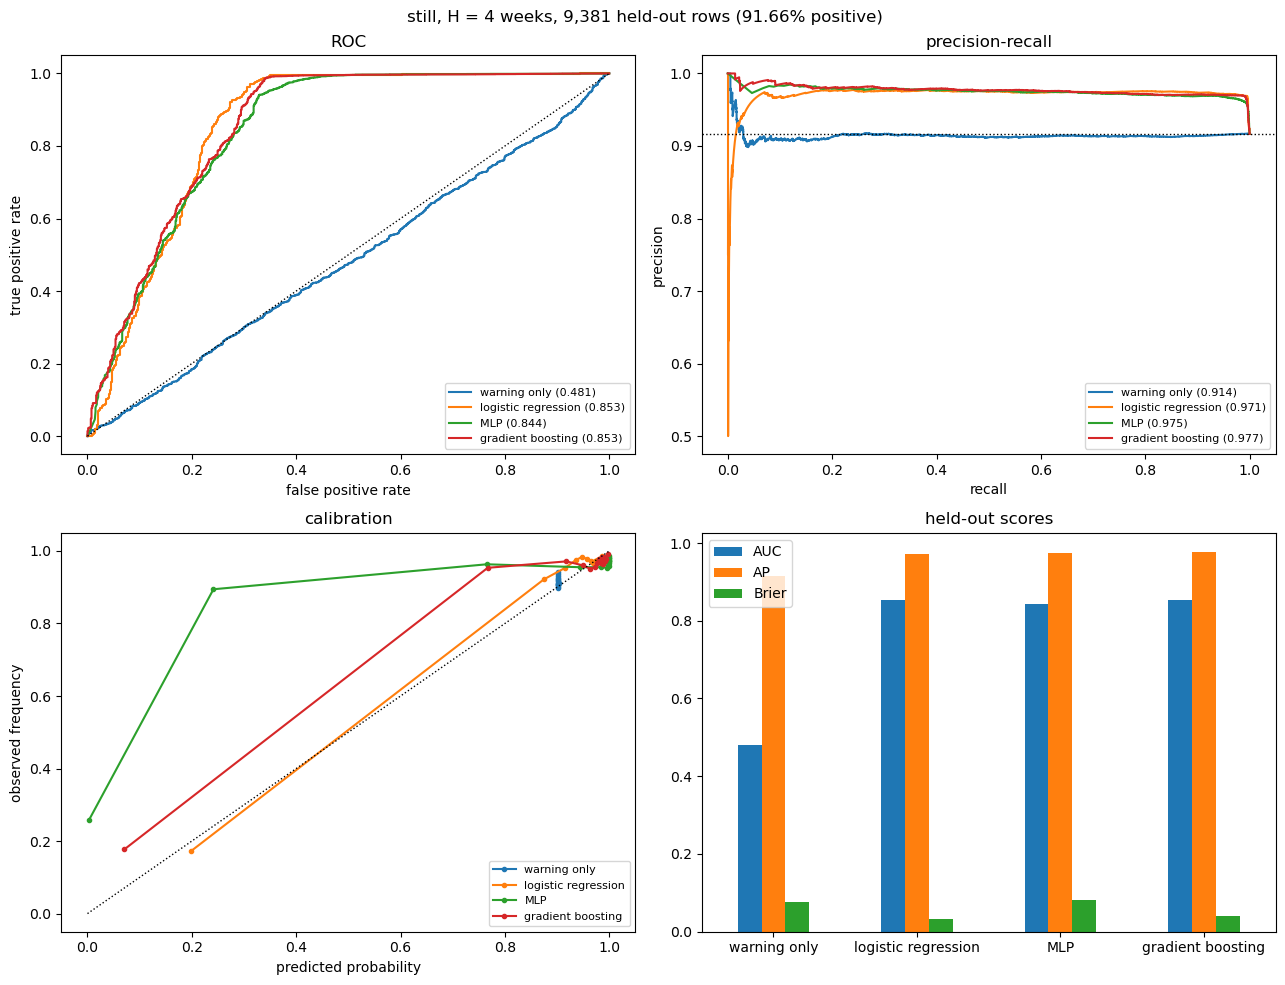

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
for n, r in results.items():
    fpr, tpr, _ = roc_curve(yva, r["p"])
    ax[0, 0].plot(fpr, tpr, label=f"{n} ({roc_auc_score(yva, r['p']):.3f})")
    prec, rec, _ = precision_recall_curve(yva, r["p"])
    ax[0, 1].plot(rec, prec, label=f"{n} ({average_precision_score(yva, r['p']):.3f})")
    frac, mean = calibration_curve(yva, r["p"], n_bins=15, strategy="quantile")
    ax[1, 0].plot(mean, frac, "o-", ms=3, label=n)
ax[0, 0].plot([0, 1], [0, 1], "k:", lw=1)
ax[0, 0].set(title="ROC", xlabel="false positive rate", ylabel="true positive rate")
ax[0, 1].axhline(yva.mean(), color="k", ls=":", lw=1)
ax[0, 1].set(title="precision-recall", xlabel="recall", ylabel="precision")
ax[1, 0].plot([0, 1], [0, 1], "k:", lw=1)
ax[1, 0].set(title="calibration", xlabel="predicted probability", ylabel="observed frequency")
table[["AUC", "AP", "Brier"]].plot.bar(ax=ax[1, 1], rot=0)
ax[1, 1].set(title="held-out scores")
for a in ax.flat[:3]:
    a.legend(fontsize=8)
fig.suptitle(f"{TASK}, H = {H} weeks, {len(yva):,} held-out rows ({yva.mean():.2%} positive)")
fig.tight_layout()

<Axes: title={'center': 'AUC by strait (held out)'}>

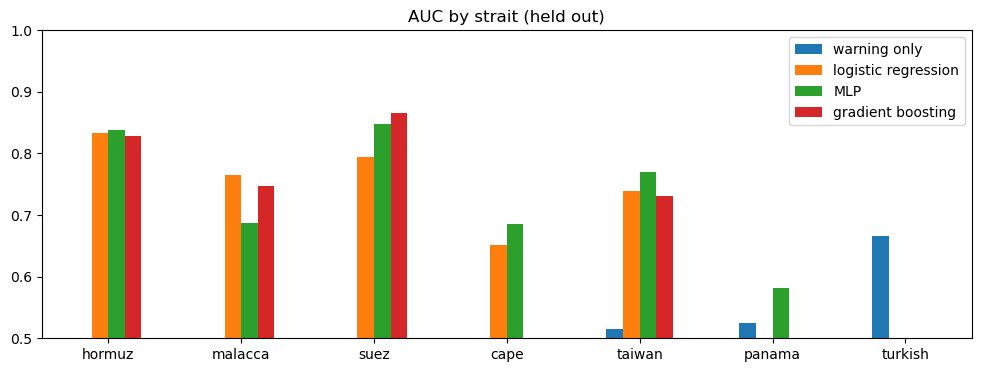

In [28]:
per = {
    n: [
        roc_auc_score(yva[str_va == i], r["p"][(str_va == i).to_numpy()]) if yva[str_va == i].nunique() == 2 else np.nan
        for i in range(C)
    ]
    for n, r in results.items()
}
pd.DataFrame(per, index=names).plot.bar(figsize=(12, 4), rot=0, title="AUC by strait (held out)", ylim=(0.5, 1))

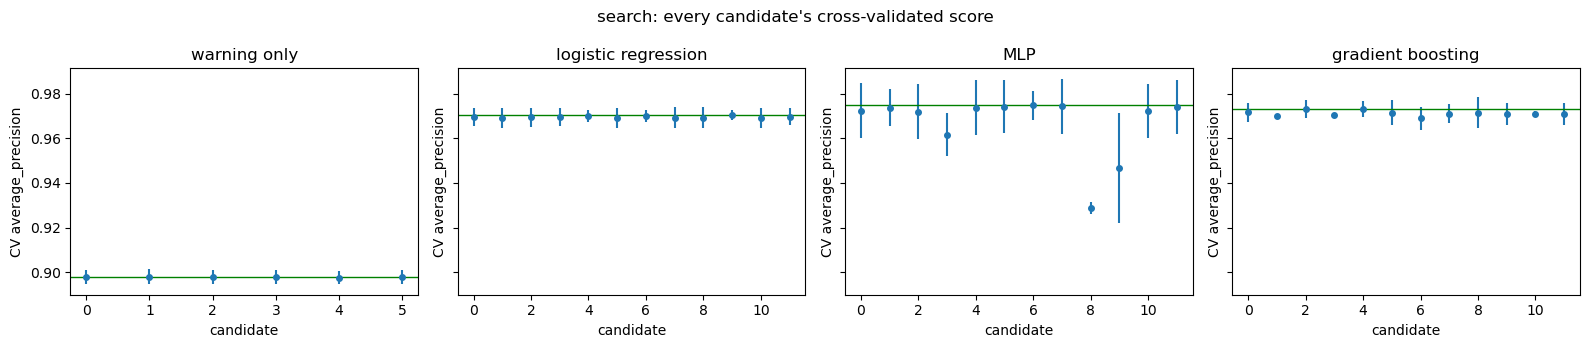

In [29]:
fig, ax = plt.subplots(1, len(results), figsize=(4 * len(results), 3.5), sharey=True)
for a, (n, r) in zip(np.atleast_1d(ax), results.items()):
    cv = r["cv"]
    a.errorbar(range(len(cv)), cv["mean_test_score"], yerr=cv["std_test_score"], fmt="o", ms=4)
    a.axhline(cv["mean_test_score"].max(), color="g", lw=1)
    a.set(title=n, xlabel="candidate", ylabel=f"CV {SCORING}")
fig.suptitle("search: every candidate's cross-validated score")
fig.tight_layout()

## Horizons: the best of each method, refit for every H

,method,H,positive,AUC,AP,Brier,LogLoss
0,warning only,1,0.9720,0.4771,0.9711,0.0273,0.1284
1,logistic regression,1,0.9720,0.9035,0.9948,0.0194,0.0733
2,MLP,1,0.9720,0.8679,0.9936,0.0246,0.0995
3,gradient boosting,1,0.9720,0.9064,0.9955,0.0215,0.0788
4,warning only,2,0.9431,0.4745,0.9386,0.0538,0.2196
5,logistic regression,2,0.9431,0.8933,0.9867,0.0250,0.1073
6,MLP,2,0.9431,0.8964,0.9881,0.0253,0.1080
7,gradient boosting,2,0.9431,0.8979,0.9902,0.0338,0.1340
8,warning only,4,0.9166,0.4815,0.9143,0.0766,0.2882
9,logistic regression,4,0.9166,0.8527,0.9711,0.0329,0.1500


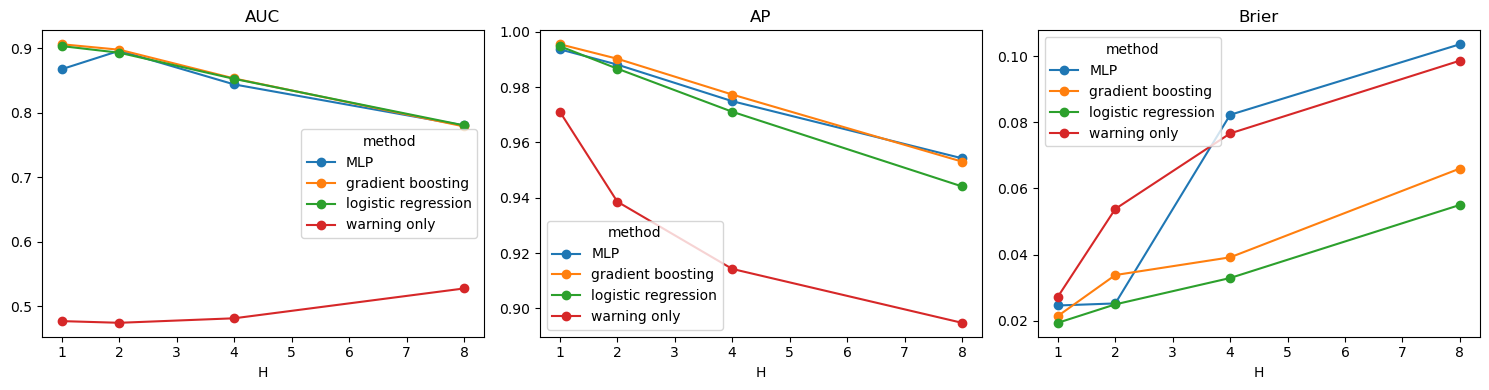

In [30]:
by_h = []
for h in HORIZONS:
    Xh, yh, _, _ = task_xy(train, h=h)
    Xvh, yvh, _, _ = task_xy(valid, h=h)
    for n, r in results.items():
        p = clone(r["model"]).fit(Xh, yh).predict_proba(Xvh)[:, 1]
        by_h.append({"method": n, "H": h, "positive": yvh.mean(), **scores(yvh, p)})
by_h = pd.DataFrame(by_h)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, metric in zip(ax, ("AUC", "AP", "Brier")):
    by_h.pivot(index="H", columns="method", values=metric).plot(ax=a, marker="o", title=metric)
fig.tight_layout()
by_h.round(4)

## What the logistic regression reads

<Axes: title={'center': 'standardised coefficients'}>

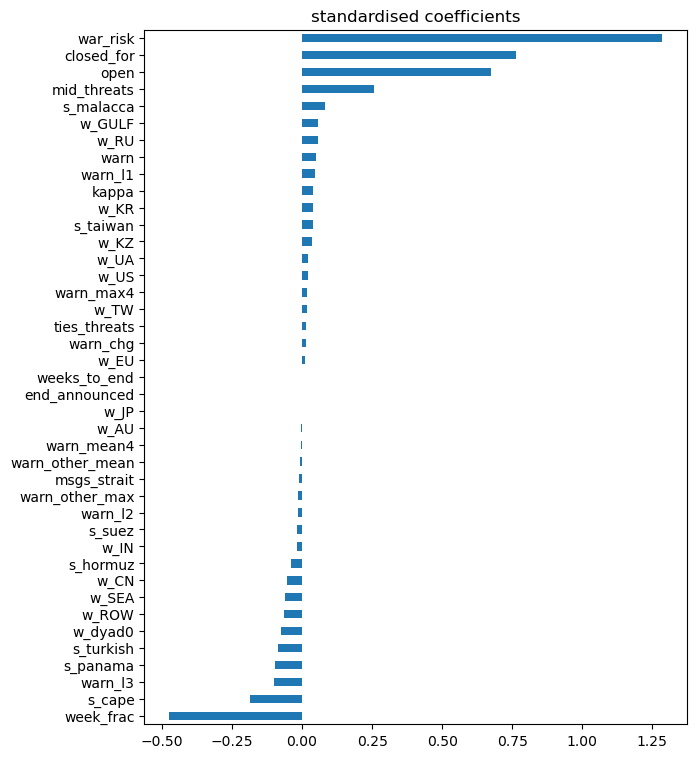

In [31]:
lr = results["logistic regression"]["model"]
coef = pd.Series(lr[-1].coef_[0], index=FEATURES).sort_values()
coef.plot.barh(figsize=(7, 0.22 * len(coef)), title="standardised coefficients")

In [32]:
out = ROOT / "experiments/results" / f"classifiers_{TASK}_h{H}.csv"
table.to_csv(out)
out

PosixPath('/Users/oles/UCU/Secrethon/shockbench-flow-starter/experiments/results/classifiers_still_h4.csv')